<div style="text-align: center; margin-top: 200px; margin-bottom: 100px;">

# Machine Learning for Data Analytics  
## Assignment 7

<br><br>

**Piotr Czech, Filip Miśkiewicz**

</div>

In [1]:
%%html
<style>
img {
    max-width: 1050px !important;
    margin: 20px auto !important;
    display: block !important;
    border: 2px solid #ccc !important;
    padding: 60px 30px !important;
}
</style>

In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("RAY_DEDUP_LOGS", "0")

import copy
import logging
import random
import time
import warnings
from collections import OrderedDict

import flwr as fl
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from flwr.common import ndarrays_to_parameters
from flwr.common.logger import update_console_handler
from IPython.display import display
from opacus import PrivacyEngine
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms

warnings.filterwarnings('ignore')


In [3]:
random_state = 333
# Reproducibility
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)
np.random.seed(random_state)
random.seed(random_state)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
flower_device = torch.device('cpu')
print(f'Using device: {device}')
print(f'Using device for Flower simulation: {flower_device}')


Using device: cuda
Using device for Flower simulation: cpu


## Table of Contents

* [Problem 7.1: Federated Learning](#problem-71-federated-learning)
* [Problem 7.2: Differential Privacy](#problem-72-differential-privacy)
* [Problem 7.3: MLOps Pipeline](#problem-73-mlops-pipeline)

## Problem 7.1: Federated Learning

### Objective
Implement federated learning using Flower

### Tasks
- Simulate 5 clients with non-IID data splits (MNIST).
- Implement FedAvg algorithm.
- Track model performance at each communication round.
- Compare with centralized training.

In classical machine learning we usually move all data into one central place. In federated learning the idea is reversed: data stays on clients and only model weights are exchanged. The workflow is:

1. server sends global model weights to clients
2. each client trains local model on its private data, here only for 1 epoch
3. clients send updated weights back to the server
4. server aggregates them with FedAvg
5. the next communication round starts

So the training data never leaves the client. In this exercise we simulate this setup on MNIST.

First we load MNIST. It contains grayscale 28x28 images of handwritten digits from 0 to 9. We use the original train and test split from `torchvision`.

In [4]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(
    root='./../datasets',
    train=True,
    download=True,
    transform=mnist_transform,
)

test_dataset = datasets.MNIST(
    root='./../datasets',
    train=False,
    download=True,
    transform=mnist_transform,
)

batch_size = 128
test_batch_size = 512
num_workers = 0

train_loader_full = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    generator=torch.Generator().manual_seed(random_state),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=test_batch_size,
    shuffle=False,
    num_workers=num_workers,
)

print(f'Train samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

sample_images, sample_labels = next(iter(train_loader_full))
print(f'One batch shape: {sample_images.shape}')
print(f'Example labels: {sample_labels[:12].tolist()}')


Train samples: 60000
Test samples: 10000
One batch shape: torch.Size([128, 1, 28, 28])
Example labels: [5, 7, 6, 6, 7, 3, 3, 6, 7, 9, 6, 0]


now lets create non-iid clients. Each client receives only two digits. This is artificial, but it imitates a real case where different users or institutions have different data distributions.

In [5]:
client_digit_groups = {
    0: [0, 1],
    1: [2, 3],
    2: [4, 5],
    3: [6, 7],
    4: [8, 9],
}

train_targets = np.array(train_dataset.targets)
client_indices = []
client_rows = []

for client_id, digits in client_digit_groups.items():
    indices = np.where(np.isin(train_targets, digits))[0]
    rng = np.random.default_rng(random_state + client_id)
    indices = rng.permutation(indices)
    client_indices.append(indices.tolist())

    labels = train_targets[indices]
    row = {'client': f'client {client_id}', 'digits': str(digits), 'samples': len(indices)}
    for digit in range(10):
        row[str(digit)] = int((labels == digit).sum())
    client_rows.append(row)

all_client_indices = np.concatenate([np.array(indices) for indices in client_indices])
print(f'Assigned samples: {len(all_client_indices)}')
print(f'Unique assigned samples: {len(np.unique(all_client_indices))}')
print(f'Train dataset samples: {len(train_dataset)}')

client_distribution_df = pd.DataFrame(client_rows)
display(client_distribution_df)


Assigned samples: 60000
Unique assigned samples: 60000
Train dataset samples: 60000


,client,digits,samples,0,1,2,3,4,5,6,7,8,9
0,client 0,"[0, 1]",12665,5923,6742,0,0,0,0,0,0,0,0
1,client 1,"[2, 3]",12089,0,0,5958,6131,0,0,0,0,0,0
2,client 2,"[4, 5]",11263,0,0,0,0,5842,5421,0,0,0,0
3,client 3,"[6, 7]",12183,0,0,0,0,0,0,5918,6265,0,0
4,client 4,"[8, 9]",11800,0,0,0,0,0,0,0,0,5851,5949


As we see, every client has only two digits and zero examples of the other classes. The full `60000` training samples are still assigned exactly once, but local distributions are very different. This is a strong non-IID split: client 0 can only learn `0/1` locally, client 4 only `8/9`, etc. In real federated learning it can happen when users or institutions naturally collect different kinds of data.

In [6]:
client_loaders = []
for client_id, indices in enumerate(client_indices):
    loader = DataLoader(
        Subset(train_dataset, indices),
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )
    client_loaders.append(loader)

print(f'Number of client loaders: {len(client_loaders)}')
print(f'Client dataset sizes: {[len(loader.dataset) for loader in client_loaders]}')


Number of client loaders: 5
Client dataset sizes: [12665, 12089, 11263, 12183, 11800]


Now we define a small convolutional neural network. It is enough for MNIST and it trains quite fast. The output layer has 10 neurons, one for each digit.

In [7]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)


dry_model = MNISTCNN().to(device)
dry_model.eval()
with torch.no_grad():
    dry_outputs = dry_model(sample_images[:8].to(device))

print(f'Dry forward output shape: {dry_outputs.shape}')
print(f'Number of model parameters: {sum(p.numel() for p in dry_model.parameters()):,}')
del dry_model


Dry forward output shape: torch.Size([8, 10])
Number of model parameters: 105,866


The helper functions below are used both by Flower clients and by the centralized baseline. Flower works with NumPy arrays, so we also add functions for getting and setting model weights.

In [8]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
local_epochs = 1
num_clients = 5
num_rounds = 5


def get_model_parameters(model):
    return [value.cpu().numpy() for value in model.state_dict().values()]


def set_model_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({key: torch.tensor(value) for key, value in params_dict})
    model.load_state_dict(state_dict, strict=True)


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate_model(model, loader, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


Now we define the Flower client. Every client has its own dataloader and local model. In `fit` it receives global weights, trains locally for one epoch, and returns only updated weights to the server.

In [9]:
class FlowerMNISTClient(fl.client.NumPyClient):
    def __init__(self, client_id, train_loader, local_epochs=1):
        self.client_id = client_id
        self.train_loader = train_loader
        self.local_epochs = local_epochs
        self.model = MNISTCNN().to(flower_device)

    def get_parameters(self, config):
        return get_model_parameters(self.model)

    def fit(self, parameters, config):
        set_model_parameters(self.model, parameters)
        optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)

        train_loss = None
        train_acc = None
        for _ in range(self.local_epochs):
            train_loss, train_acc = train_one_epoch(
                self.model,
                self.train_loader,
                optimizer,
                flower_device,
            )

        return (
            get_model_parameters(self.model),
            len(self.train_loader.dataset),
            {
                'train_loss': float(train_loss),
                'train_acc': float(train_acc),
            },
        )


Before running Flower, we create an initial global model. The same initial weights will also be used by the centralized baseline, so the comparison starts from the same point.

In [10]:
initial_model = MNISTCNN().to(flower_device)
initial_state = copy.deepcopy(initial_model.state_dict())
initial_parameters = ndarrays_to_parameters(get_model_parameters(initial_model))

fl_global_model = MNISTCNN().to(flower_device)
fl_history_rows = []


def evaluate_fn(server_round, parameters, config):
    set_model_parameters(fl_global_model, parameters)
    test_loss, test_acc = evaluate_model(fl_global_model, test_loader, flower_device)
    fl_history_rows.append({
        'round': server_round,
        'test_loss': test_loss,
        'test_acc': test_acc,
    })
    return test_loss, {'accuracy': test_acc}


def fit_metrics_aggregation_fn(metrics):
    total_examples = sum(num_examples for num_examples, _ in metrics)
    aggregated = {}
    for metric_name in ['train_loss', 'train_acc']:
        aggregated[metric_name] = sum(
            num_examples * metric_values[metric_name]
            for num_examples, metric_values in metrics
        ) / total_examples
    return aggregated


def client_fn(context):
    client_id = int(context.node_config['partition-id'])
    return FlowerMNISTClient(
        client_id=client_id,
        train_loader=client_loaders[client_id],
        local_epochs=local_epochs,
    ).to_client()


lets run the federated learning simulation. We use all 5 clients in every round and FedAvg as the aggregation strategy.

In [11]:
update_console_handler(level='ERROR')
logging.getLogger('ray').setLevel(logging.ERROR)

strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=num_clients,
    min_available_clients=num_clients,
    evaluate_fn=evaluate_fn,
    initial_parameters=initial_parameters,
    fit_metrics_aggregation_fn=fit_metrics_aggregation_fn,
)

start = time.time()
fl_history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=num_clients,
    config=fl.server.ServerConfig(num_rounds=num_rounds),
    strategy=strategy,
    client_resources={'num_cpus': 1, 'num_gpus': 0.0},
    ray_init_args={
        'ignore_reinit_error': True,
        'include_dashboard': False,
        'log_to_driver': False,
        'logging_level': logging.ERROR,
    },
)
fl_elapsed = time.time() - start

try:
    import ray
    if ray.is_initialized():
        ray.shutdown()
except Exception:
    pass

print(f'Flower simulation took {fl_elapsed:.1f} seconds')


06/14/2026 19:58:35:WARNING:DEPRECATED FEATURE: flwr.simulation.start_simulation() is deprecated.
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        


Flower simulation took 31.7 seconds


In [12]:
fl_history_df = pd.DataFrame(fl_history_rows)
fl_rounds_df = fl_history_df[fl_history_df['round'] > 0].copy()

fl_display_df = fl_rounds_df.copy()
for col in ['test_loss', 'test_acc']:
    fl_display_df[col] = fl_display_df[col].round(4)

display(fl_display_df)

final_fl_row = fl_rounds_df.iloc[-1]
print(f"Federated final test accuracy: {final_fl_row['test_acc']:.4f}")
print(f"Federated final test loss: {final_fl_row['test_loss']:.4f}")


,round,test_loss,test_acc
1,1,1.8840,0.4998
2,2,1.5220,0.5270
3,3,1.2684,0.6479
4,4,1.1230,0.6615
5,5,1.0757,0.6694


Federated final test accuracy: 0.6694
Federated final test loss: 1.0757


The federated model is learning, but quite slowly. Test accuracy grows from about `0.50` after the first round to about `0.67` after round 5, and loss drops from about `1.88` to `1.08`. This means FedAvg combines useful updates from clients, but the non-IID split makes the task harder. Every local model trains only on two digits, so its update is biased before averaging.

For comparison we now train the same CNN in the normal centralized way. This model sees the full training dataset in every epoch. The number of epochs is equal to the number of federated communication rounds.

In [13]:
centralized_model = MNISTCNN().to(device)
centralized_model.load_state_dict(copy.deepcopy(initial_state))
centralized_optimizer = torch.optim.Adam(centralized_model.parameters(), lr=learning_rate)

centralized_history = []
start = time.time()

for epoch in range(1, num_rounds + 1):
    train_loss, train_acc = train_one_epoch(
        centralized_model,
        train_loader_full,
        centralized_optimizer,
        device,
    )
    test_loss, test_acc = evaluate_model(centralized_model, test_loader, device)

    centralized_history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
    })

    print(
        f"epoch {epoch}: "
        f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
        f"test loss={test_loss:.4f}, test acc={test_acc:.4f}"
    )

centralized_elapsed = time.time() - start
centralized_history_df = pd.DataFrame(centralized_history)
print(f'Centralized training took {centralized_elapsed:.1f} seconds')

centralized_display_df = centralized_history_df.copy()
for col in ['train_loss', 'train_acc', 'test_loss', 'test_acc']:
    centralized_display_df[col] = centralized_display_df[col].round(4)

display(centralized_display_df)

final_centralized_row = centralized_history_df.iloc[-1]
print(f"Centralized final test accuracy: {final_centralized_row['test_acc']:.4f}")
print(f"Centralized final test loss: {final_centralized_row['test_loss']:.4f}")


epoch 1: train loss=0.3012, train acc=0.9097, test loss=0.0722, test acc=0.9763
epoch 2: train loss=0.0867, train acc=0.9739, test loss=0.0493, test acc=0.9846
epoch 3: train loss=0.0639, train acc=0.9807, test loss=0.0356, test acc=0.9872
epoch 4: train loss=0.0518, train acc=0.9844, test loss=0.0333, test acc=0.9889
epoch 5: train loss=0.0427, train acc=0.9865, test loss=0.0369, test acc=0.9887
Centralized training took 39.1 seconds


,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.3012,0.9098,0.0722,0.9763
1,2,0.0867,0.9739,0.0493,0.9846
2,3,0.0639,0.9807,0.0356,0.9872
3,4,0.0518,0.9844,0.0333,0.9889
4,5,0.0427,0.9865,0.0369,0.9887


Centralized final test accuracy: 0.9887
Centralized final test loss: 0.0369


Centralized training is much stronger here. After only one epoch the test accuracy is already about `0.98`, and after 5 epochs it stays close to `0.99`. The loss is also very small. This happens because the centralized model sees all digits mixed together in every epoch, so it does not have the same client distribution problem.

Finally we compare both approaches on the test set. In the plot, one federated round is compared with one centralized epoch.

In [14]:
comparison_df = pd.DataFrame([
    {
        'method': 'federated',
        'step': int(final_fl_row['round']),
        'test_loss': final_fl_row['test_loss'],
        'test_acc': final_fl_row['test_acc'],
        'time_sec': fl_elapsed,
    },
    {
        'method': 'centralized',
        'step': int(final_centralized_row['epoch']),
        'test_loss': final_centralized_row['test_loss'],
        'test_acc': final_centralized_row['test_acc'],
        'time_sec': centralized_elapsed,
    },
])

comparison_display_df = comparison_df.copy()
for col in ['test_loss', 'test_acc']:
    comparison_display_df[col] = comparison_display_df[col].round(4)
comparison_display_df['time_sec'] = comparison_display_df['time_sec'].round(1)
display(comparison_display_df)


,method,step,test_loss,test_acc,time_sec
0,federated,5,1.0757,0.6694,31.7
1,centralized,5,0.0369,0.9887,39.1


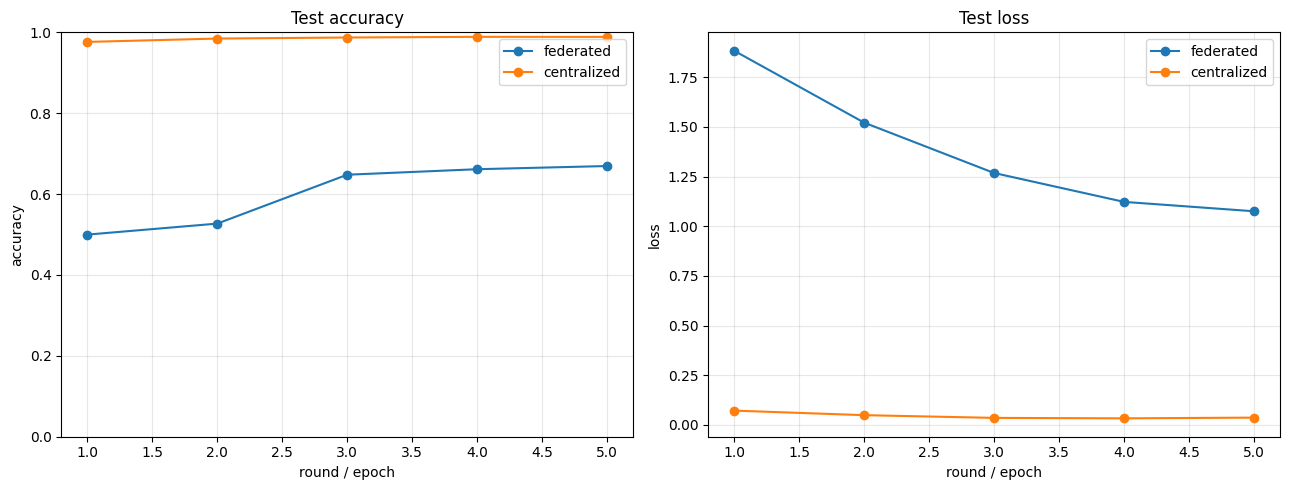

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    fl_rounds_df['round'],
    fl_rounds_df['test_acc'],
    marker='o',
    label='federated',
)
axes[0].plot(
    centralized_history_df['epoch'],
    centralized_history_df['test_acc'],
    marker='o',
    label='centralized',
)
axes[0].set_title('Test accuracy')
axes[0].set_xlabel('round / epoch')
axes[0].set_ylabel('accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    fl_rounds_df['round'],
    fl_rounds_df['test_loss'],
    marker='o',
    label='federated',
)
axes[1].plot(
    centralized_history_df['epoch'],
    centralized_history_df['test_loss'],
    marker='o',
    label='centralized',
)
axes[1].set_title('Test loss')
axes[1].set_xlabel('round / epoch')
axes[1].set_ylabel('loss')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


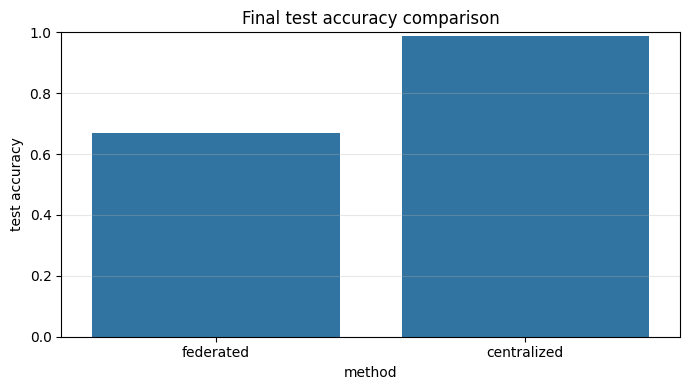

In [16]:
plt.figure(figsize=(7, 4))
sns.barplot(data=comparison_df, x='method', y='test_acc')
plt.title('Final test accuracy comparison')
plt.xlabel('method')
plt.ylabel('test accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Clearly, accuracy of the centralized is much higher.

One more useful check is to train federated learning for more communication rounds. We keep `local_epochs = 1`, because with non-IID clients too many local epochs can make every client move too much toward its own two digits. Here we only ask: if FedAvg gets more rounds, does it get close to centralized training?

In [17]:
long_num_rounds = 20
long_fl_global_model = MNISTCNN().to(flower_device)
long_fl_history_rows = []

long_initial_model = MNISTCNN().to(flower_device)
long_initial_model.load_state_dict(copy.deepcopy(initial_state))
long_initial_parameters = ndarrays_to_parameters(get_model_parameters(long_initial_model))


def long_evaluate_fn(server_round, parameters, config):
    set_model_parameters(long_fl_global_model, parameters)
    test_loss, test_acc = evaluate_model(long_fl_global_model, test_loader, flower_device)
    long_fl_history_rows.append({
        'round': server_round,
        'test_loss': test_loss,
        'test_acc': test_acc,
    })
    return test_loss, {'accuracy': test_acc}


long_strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=num_clients,
    min_available_clients=num_clients,
    evaluate_fn=long_evaluate_fn,
    initial_parameters=long_initial_parameters,
    fit_metrics_aggregation_fn=fit_metrics_aggregation_fn,
)

start = time.time()
long_fl_history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=num_clients,
    config=fl.server.ServerConfig(num_rounds=long_num_rounds),
    strategy=long_strategy,
    client_resources={'num_cpus': 1, 'num_gpus': 0.0},
    ray_init_args={
        'ignore_reinit_error': True,
        'include_dashboard': False,
        'log_to_driver': False,
        'logging_level': logging.ERROR,
    },
)
long_fl_elapsed = time.time() - start

try:
    import ray
    if ray.is_initialized():
        ray.shutdown()
except Exception:
    pass

print(f'Longer Flower simulation took {long_fl_elapsed:.1f} seconds')


Longer Flower simulation took 97.0 seconds


In [18]:
long_fl_history_df = pd.DataFrame(long_fl_history_rows)
long_fl_rounds_df = long_fl_history_df[long_fl_history_df['round'] > 0].copy()

long_fl_display_df = long_fl_rounds_df.copy()
for col in ['test_loss', 'test_acc']:
    long_fl_display_df[col] = long_fl_display_df[col].round(4)

display(long_fl_display_df)

final_long_fl_row = long_fl_rounds_df.iloc[-1]
print(f"Long federated final test accuracy: {final_long_fl_row['test_acc']:.4f}")
print(f"Long federated final test loss: {final_long_fl_row['test_loss']:.4f}")


,round,test_loss,test_acc
1,1,1.8992,0.4828
2,2,1.4788,0.5631
3,3,1.2427,0.6404
4,4,1.1035,0.6771
5,5,1.0277,0.6923
6,6,0.9512,0.7119
7,7,0.8852,0.7352
8,8,0.9058,0.7150
9,9,0.8137,0.7381
10,10,0.8522,0.7223


Long federated final test accuracy: 0.7675
Long federated final test loss: 0.7131


With more communication rounds the federated model improves a lot. Accuracy goes from about `0.48` in round 1 to about `0.77` in round 20, and loss drops from about `1.89` to `0.71`. The curve is not perfectly smooth, but the trend is clearly positive. This suggests that FedAvg can keep learning from these non-IID clients, but it needs many more rounds than the centralized model needs epochs.

In [19]:
long_comparison_df = pd.DataFrame([
    {
        'method': 'federated 5 rounds',
        'test_loss': final_fl_row['test_loss'],
        'test_acc': final_fl_row['test_acc'],
        'time_sec': fl_elapsed,
    },
    {
        'method': 'federated 20 rounds',
        'test_loss': final_long_fl_row['test_loss'],
        'test_acc': final_long_fl_row['test_acc'],
        'time_sec': long_fl_elapsed,
    },
    {
        'method': 'centralized 5 epochs',
        'test_loss': final_centralized_row['test_loss'],
        'test_acc': final_centralized_row['test_acc'],
        'time_sec': centralized_elapsed,
    },
])

long_comparison_display_df = long_comparison_df.copy()
for col in ['test_loss', 'test_acc']:
    long_comparison_display_df[col] = long_comparison_display_df[col].round(4)
long_comparison_display_df['time_sec'] = long_comparison_display_df['time_sec'].round(1)
display(long_comparison_display_df)


,method,test_loss,test_acc,time_sec
0,federated 5 rounds,1.0757,0.6694,31.7
1,federated 20 rounds,0.7131,0.7675,97.0
2,centralized 5 epochs,0.0369,0.9887,39.1


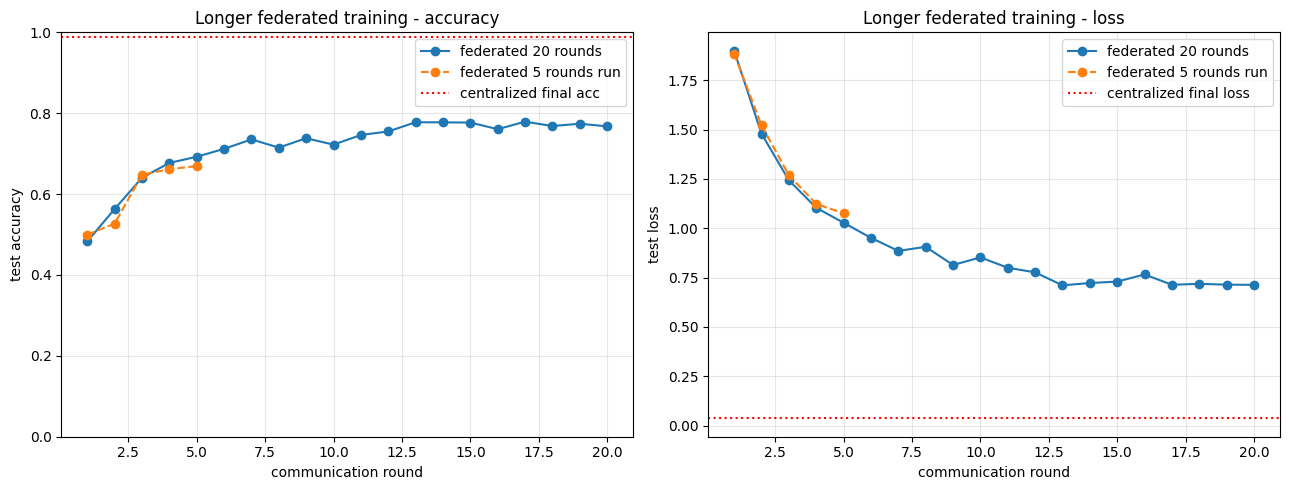

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    long_fl_rounds_df['round'],
    long_fl_rounds_df['test_acc'],
    marker='o',
    label='federated 20 rounds',
)
axes[0].plot(
    fl_rounds_df['round'],
    fl_rounds_df['test_acc'],
    marker='o',
    linestyle='--',
    label='federated 5 rounds run',
)
axes[0].axhline(
    final_centralized_row['test_acc'],
    color='red',
    linestyle=':',
    label='centralized final acc',
)
axes[0].set_title('Longer federated training - accuracy')
axes[0].set_xlabel('communication round')
axes[0].set_ylabel('test accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    long_fl_rounds_df['round'],
    long_fl_rounds_df['test_loss'],
    marker='o',
    label='federated 20 rounds',
)
axes[1].plot(
    fl_rounds_df['round'],
    fl_rounds_df['test_loss'],
    marker='o',
    linestyle='--',
    label='federated 5 rounds run',
)
axes[1].axhline(
    final_centralized_row['test_loss'],
    color='red',
    linestyle=':',
    label='centralized final loss',
)
axes[1].set_title('Longer federated training - loss')
axes[1].set_xlabel('communication round')
axes[1].set_ylabel('test loss')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


The longer run answers the question: more rounds help, but they still do not close the gap. Going from 5 to 20 FL rounds improves accuracy from about `0.70` to about `0.78`. Still, centralized training after only 5 epochs is around `0.99`. So in this setup the bottleneck is not only training time, but also the very strong non-IID split.

### Conclusions

Overall, Flower simulation worked and FedAvg improved the global MNIST model without moving client data to the server. In the short 5-round run it reached significantly lower accuracy than the centralized. The extra 20-round FL run improved the result to about `0.78`, so more communication rounds definitely help. But it still did not get close to centralized learning, mostly because every client has only two digit classes and local updates are very biased.

## Problem 7.2: Differential Privacy

### Objective
Apply differential privacy to neural network training

### Tasks
- Use Opacus library with PyTorch.
- Train on sensitive dataset (e.g., Adult Income).
- Experiment with different epsilon values (1.0, 5.0, 10.0).
- Analyze privacy-utility tradeoff

Differential privacy is used when we want to train a model, but we do not want one single training person to have too much influence on the final weights. In deep learning this is usually done in three steps:
- calculate gradients per sample,
- clip their norm,
- add calibrated random noise.

The privacy budget is called `epsilon`. Smaller `epsilon` means stronger privacy but usually worse model quality. A normal model without DP can be treated like `epsilon = infinity`, because we do not add this protection.

First we load the Adult Income dataset. This is the same dataset as in Problem 2.1. We use almost the same cleaning: missing values marked as `?` are removed, target is changed to 0/1, and the duplicated `education` column is dropped.

In [21]:
adult_income_df = pd.read_csv('./../datasets/adult-income-dataset.csv')
adult_income_df = adult_income_df.replace('?', np.nan)

before_dropna = adult_income_df.shape
adult_dp = adult_income_df.dropna().copy()
after_dropna = adult_dp.shape

adult_dp['income'] = adult_dp['income'].map({'<=50K': 0, '>50K': 1})
adult_dp.drop(columns=['education'], inplace=True)

print(f'Before dropping nan values: {before_dropna}')
print(f'After dropping nan values: {after_dropna}')
print(f'Dropped rows: {before_dropna[0] - after_dropna[0]}')
display(adult_dp.head())

Before dropping nan values: (48842, 15)
After dropping nan values: (45222, 15)
Dropped rows: 3620


,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,198693,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


After cleaning we still have `45222` rows from the original `48842`, so the dataset is still large enough for a neural network. We removed `3620` rows with missing values, because Opacus and PyTorch training need clean numeric tensors. The `education` text column is also removed because `educational-num` keeps the same information in numeric form.

Like before, `native-country` has many categories. For this task we do not need very detailed country level information, so we map countries into a few regions. It keeps the input smaller and easier for the neural network.

In [22]:
def map_country_to_region(country):
    europe = {
        'England', 'Germany', 'Greece', 'Italy', 'Poland', 'Portugal',
        'France', 'Ireland', 'Scotland', 'Hungary', 'Yugoslavia',
        'Holand-Netherlands'
    }
    asia = {
        'India', 'Japan', 'China', 'Iran', 'Philippines', 'Vietnam',
        'Cambodia', 'Thailand', 'Laos', 'Taiwan', 'Hong', 'South'
    }
    latin_america = {
        'Mexico', 'Puerto-Rico', 'Honduras', 'Jamaica', 'Cuba',
        'Dominican-Republic', 'El-Salvador', 'Guatemala', 'Haiti',
        'Nicaragua', 'Peru', 'Ecuador', 'Trinadad&Tobago', 'Columbia'
    }

    if country == 'United-States':
        return 'United-States'
    if country in europe:
        return 'Europe'
    if country in asia:
        return 'Asia'
    if country in latin_america:
        return 'Latin-America'
    return 'Other'


adult_dp['native-country'] = adult_dp['native-country'].apply(map_country_to_region)

X_adult = adult_dp.drop(columns=['income'])
y_adult = adult_dp['income']

categorical_cols = X_adult.select_dtypes(include='str').columns.tolist()
numeric_cols = X_adult.select_dtypes(exclude='str').columns.tolist()

print(f'Categorical columns: {categorical_cols}')
print(f'Numeric columns: {numeric_cols}')
print(f'Native country groups: {sorted(adult_dp["native-country"].unique())}')

Categorical columns: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
Numeric columns: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Native country groups: ['Asia', 'Europe', 'Latin-America', 'Other', 'United-States']


In [23]:
class_distribution_df = (
    y_adult.value_counts()
    .sort_index()
    .rename(index={0: '<=50K', 1: '>50K'})
    .reset_index()
)
class_distribution_df.columns = ['income', 'count']
class_distribution_df['share'] = class_distribution_df['count'] / class_distribution_df['count'].sum()

class_distribution_display_df = class_distribution_df.copy()
class_distribution_display_df['share'] = class_distribution_display_df['share'].round(3)
display(class_distribution_display_df)

,income,count,share
0,<=50K,34014,0.752
1,>50K,11208,0.248


The target is imbalanced: around `75%` of rows are `<=50K`, and only around `25%` are `>50K`. Because of that, accuracy can look good even when the model is weak on the positive class. So in the next tables we also track F1, ROC-AUC and PR-AUC.

Now we make a standard stratified train-test split. Numeric columns are scaled and categorical columns are one-hot encoded. This is important for MLP, because it works on numeric vectors and usually trains better when numeric features have similar scale.

In [24]:
X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(
    X_adult,
    y_adult,
    test_size=0.2,
    random_state=random_state,
    stratify=y_adult,
)

adult_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ],
    verbose_feature_names_out=False,
)

X_train_adult_enc = adult_preprocessor.fit_transform(X_train_adult).astype(np.float32)
X_test_adult_enc = adult_preprocessor.transform(X_test_adult).astype(np.float32)
feature_names_adult = adult_preprocessor.get_feature_names_out()

y_train_adult_np = y_train_adult.to_numpy(dtype=np.int64)
y_test_adult_np = y_test_adult.to_numpy(dtype=np.int64)

adult_split_df = pd.DataFrame([
    {'split': 'train', 'rows': X_train_adult_enc.shape[0], 'features': X_train_adult_enc.shape[1], 'positive_share': y_train_adult_np.mean()},
    {'split': 'test', 'rows': X_test_adult_enc.shape[0], 'features': X_test_adult_enc.shape[1], 'positive_share': y_test_adult_np.mean()},
])
adult_split_display_df = adult_split_df.copy()
adult_split_display_df['positive_share'] = adult_split_display_df['positive_share'].round(3)
display(adult_split_display_df)

print(f'Encoded input dimension: {X_train_adult_enc.shape[1]}')
print(f'First 10 encoded features: {feature_names_adult[:10].tolist()}')

,split,rows,features,positive_share
0,train,36177,52,0.248
1,test,9045,52,0.248


Encoded input dimension: 52
First 10 encoded features: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc']


The train and test sets keep almost the same positive class share, because we used stratification. The final split has `36177` train rows and `9045` test rows. After one-hot encoding the input has `52` features, so a small MLP should be enough.

Below we define the classifier and training helpers. To make the comparison more fair, we first do a very small Optuna search on a validation split. After that, the same selected architecture and learning rate are used for non-DP and all DP runs.

First we convert prepared arrays into PyTorch tensors. The final train dataset still contains the full training split, but for Optuna we also create a small train/validation split inside it.

In [25]:
X_train_tensor = torch.tensor(X_train_adult_enc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_adult_np, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_adult_enc, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_adult_np, dtype=torch.long)

adult_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
adult_test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

adult_all_train_indices = np.arange(len(y_train_adult_np))
adult_tune_train_indices, adult_val_indices = train_test_split(
    adult_all_train_indices,
    test_size=0.2,
    random_state=random_state,
    stratify=y_train_adult_np,
)

adult_tune_train_dataset = TensorDataset(
    X_train_tensor[adult_tune_train_indices],
    y_train_tensor[adult_tune_train_indices],
)
adult_val_dataset = TensorDataset(
    X_train_tensor[adult_val_indices],
    y_train_tensor[adult_val_indices],
)

print(f'Full train dataset size: {len(adult_train_dataset)}')
print(f'Optuna train dataset size: {len(adult_tune_train_dataset)}')
print(f'Optuna validation dataset size: {len(adult_val_dataset)}')
print(f'Test dataset size: {len(adult_test_dataset)}')

Full train dataset size: 36177
Optuna train dataset size: 28941
Optuna validation dataset size: 7236
Test dataset size: 9045


The main experiment now uses 20 epochs. The Optuna search is still small: only 5 trials, with 8 training epochs per trial. However, this is enough for a quick sanity check of model settings.

In [26]:
adult_epochs = 20
adult_batch_size = 512
adult_test_batch_size = 2048
adult_delta = 1e-5
adult_max_grad_norm = 1.0
adult_epsilons = [1.0, 5.0, 10.0]

adult_tuning_trials = 5
adult_tuning_epochs = 8
adult_default_params = {
    'hidden_dim_1': 128,
    'hidden_dim_2': 64,
    'dropout': 0.2,
    'lr': 1e-3,
    'weight_decay': 0.0,
}
adult_best_params = adult_default_params.copy()

The MLP now accepts hidden sizes and dropout as parameters. Optuna will choose them, then we freeze the best configuration for all later comparisons.

In [27]:
class AdultMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim_1=128, hidden_dim_2=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim_2, 2),
        )

    def forward(self, x):
        return self.net(x)


adult_criterion = nn.CrossEntropyLoss()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

These helper functions keep the training code compact. `make_loaders` can use either the full train set or the Optuna validation split. `build_adult_model` accepts a params dictionary, so the same function works during tuning and final experiments.

In [28]:
def make_loaders(seed, train_dataset=None, eval_dataset=None, batch_size=None):
    if train_dataset is None:
        train_dataset = adult_train_dataset
    if eval_dataset is None:
        eval_dataset = adult_test_dataset
    if batch_size is None:
        batch_size = adult_batch_size

    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        generator=generator,
    )
    eval_loader = DataLoader(
        eval_dataset,
        batch_size=adult_test_batch_size,
        shuffle=False,
        num_workers=0,
    )
    return train_loader, eval_loader


def build_adult_model(seed, params=None):
    if params is None:
        params = adult_best_params

    torch.manual_seed(seed)
    model = AdultMLP(
        input_dim=X_train_adult_enc.shape[1],
        hidden_dim_1=params['hidden_dim_1'],
        hidden_dim_2=params['hidden_dim_2'],
        dropout=params['dropout'],
    ).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params.get('weight_decay', 0.0),
    )
    return model, optimizer


def evaluate_adult(model, loader, device):
    model.eval()
    total_loss = 0.0
    total = 0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            outputs = model(features)
            loss = adult_criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    labels_np = np.array(all_labels)
    probs_np = np.array(all_probs)
    preds_np = (probs_np >= 0.5).astype(int)

    return {
        'loss': total_loss / total,
        'accuracy': accuracy_score(labels_np, preds_np),
        'precision': precision_score(labels_np, preds_np, zero_division=0),
        'recall': recall_score(labels_np, preds_np, zero_division=0),
        'f1': f1_score(labels_np, preds_np, zero_division=0),
        'roc_auc': roc_auc_score(labels_np, probs_np),
        'pr_auc': average_precision_score(labels_np, probs_np),
        'labels': labels_np,
        'probs': probs_np,
    }


def train_one_epoch_adult(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total = 0

    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(features)
        loss = adult_criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total += labels.size(0)

    return total_loss / total

Now we run the small Optuna search. The objective is validation F1, because the dataset is imbalanced and we care about the positive `>50K` class, not only overall accuracy.

In [29]:
optuna.logging.set_verbosity(optuna.logging.WARNING)


def adult_objective(trial):
    params = {
        'hidden_dim_1': trial.suggest_categorical('hidden_dim_1', [64, 128, 256]),
        'hidden_dim_2': trial.suggest_categorical('hidden_dim_2', [32, 64, 128]),
        'dropout': trial.suggest_float('dropout', 0.1, 0.4, step=0.1),
        'lr': trial.suggest_categorical('lr', [5e-4, 1e-3, 2e-3]),
        'weight_decay': trial.suggest_categorical('weight_decay', [0.0, 1e-5, 1e-4]),
    }

    train_loader, val_loader = make_loaders(
        seed=random_state + trial.number,
        train_dataset=adult_tune_train_dataset,
        eval_dataset=adult_val_dataset,
    )
    model, optimizer = build_adult_model(random_state + trial.number, params=params)

    val_metrics = None
    for epoch in range(1, adult_tuning_epochs + 1):
        train_one_epoch_adult(model, train_loader, optimizer, device)
        val_metrics = evaluate_adult(model, val_loader, device)
        trial.report(val_metrics['f1'], epoch)

    trial.set_user_attr('val_accuracy', val_metrics['accuracy'])
    trial.set_user_attr('val_f1', val_metrics['f1'])
    trial.set_user_attr('val_roc_auc', val_metrics['roc_auc'])
    trial.set_user_attr('val_pr_auc', val_metrics['pr_auc'])
    return val_metrics['f1']


adult_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=random_state),
)
adult_study.optimize(adult_objective, n_trials=adult_tuning_trials, show_progress_bar=False)

adult_tuning_rows = []
for trial in adult_study.trials:
    row = {
        'trial': trial.number,
        'val_f1': trial.user_attrs.get('val_f1'),
        'val_accuracy': trial.user_attrs.get('val_accuracy'),
        'val_roc_auc': trial.user_attrs.get('val_roc_auc'),
        'val_pr_auc': trial.user_attrs.get('val_pr_auc'),
        **trial.params,
    }
    adult_tuning_rows.append(row)

adult_tuning_df = pd.DataFrame(adult_tuning_rows).sort_values('val_f1', ascending=False)
adult_tuning_display_df = adult_tuning_df.copy()
for col in ['val_f1', 'val_accuracy', 'val_roc_auc', 'val_pr_auc', 'dropout', 'lr', 'weight_decay']:
    adult_tuning_display_df[col] = adult_tuning_display_df[col].round(4)

display(adult_tuning_display_df)

adult_best_params = adult_default_params.copy()
adult_best_params.update(adult_study.best_params)
print(f'Best validation F1: {adult_study.best_value:.4f}')
print(f'Best params: {adult_best_params}')

,trial,val_f1,val_accuracy,val_roc_auc,val_pr_auc,hidden_dim_1,hidden_dim_2,dropout,lr,weight_decay
2,2,0.6862,0.8517,0.9088,0.7810,128,32,0.3,0.0005,0.0000
4,4,0.6838,0.8541,0.9106,0.7850,128,128,0.2,0.0010,0.0001
1,1,0.6761,0.8516,0.9095,0.7821,256,128,0.4,0.0005,0.0001
3,3,0.6673,0.8507,0.9101,0.7829,256,64,0.1,0.0010,0.0000
0,0,0.6520,0.8538,0.9111,0.7847,128,64,0.1,0.0020,0.0001


Best validation F1: 0.6862
Best params: {'hidden_dim_1': 128, 'hidden_dim_2': 32, 'dropout': 0.30000000000000004, 'lr': 0.0005, 'weight_decay': 1e-05}


The small Optuna search gives a more fair starting point than choosing values by hand. The best trial reached about `0.686` validation F1 with hidden layers `128` and `32`, dropout `0.3`, learning rate `0.0005` and weight decay `1e-5`. The best two trials are close, but weaker trials are clearly lower, so this tuning step was useful.

Below we show the final model selected by the small validation search. This exact setup is used for the non-DP baseline and for every DP epsilon, so the comparison is not based on different model capacities.

In [30]:
summary_model = AdultMLP(
    input_dim=X_train_adult_enc.shape[1],
    hidden_dim_1=adult_best_params['hidden_dim_1'],
    hidden_dim_2=adult_best_params['hidden_dim_2'],
    dropout=adult_best_params['dropout'],
)

print(summary_model)
print(f'Number of parameters: {count_parameters(summary_model):,}')
print(f'Learning rate: {adult_best_params["lr"]}')
print(f'Weight decay: {adult_best_params["weight_decay"]}')

AdultMLP(
  (net): Sequential(
    (0): Linear(in_features=52, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.30000000000000004, inplace=False)
    (3): Linear(in_features=128, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.30000000000000004, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)
Number of parameters: 10,978
Learning rate: 0.0005
Weight decay: 1e-05


The selected model has about `11k` parameters, so it is even smaller than the first manual version. Optuna selected a narrower second hidden layer (`32`), stronger dropout (`0.3`) and a smaller learning rate (`0.0005`). This exact configuration is used for non-DP and every DP epsilon.

Before DP we train a normal baseline. This is our utility reference: it has no privacy noise and no gradient clipping, so it should usually reach the best performance.

In [31]:
def run_non_dp_experiment(seed=random_state):
    train_loader, test_loader = make_loaders(seed)
    model, optimizer = build_adult_model(seed)
    history = []

    start = time.time()
    for epoch in range(1, adult_epochs + 1):
        train_loss = train_one_epoch_adult(model, train_loader, optimizer, device)
        metrics = evaluate_adult(model, test_loader, device)
        row = {
            'method': 'non-DP',
            'epsilon': np.inf,
            'epoch': epoch,
            'train_loss': train_loss,
            'test_loss': metrics['loss'],
            'accuracy': metrics['accuracy'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1': metrics['f1'],
            'roc_auc': metrics['roc_auc'],
            'pr_auc': metrics['pr_auc'],
        }
        history.append(row)
        print(
            f"epoch {epoch}: "
            f"loss={row['test_loss']:.4f}, acc={row['accuracy']:.4f}, "
            f"f1={row['f1']:.4f}, roc_auc={row['roc_auc']:.4f}"
        )

    elapsed = time.time() - start
    final_metrics = evaluate_adult(model, test_loader, device)
    return model, pd.DataFrame(history), final_metrics, elapsed


non_dp_model, non_dp_history_df, non_dp_final_metrics, non_dp_elapsed = run_non_dp_experiment()

non_dp_display_df = non_dp_history_df.copy()
for col in ['train_loss', 'test_loss', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:
    non_dp_display_df[col] = non_dp_display_df[col].round(4)

display(non_dp_display_df)
print(f'Non-DP training took {non_dp_elapsed:.1f} seconds')

epoch 1: loss=0.4002, acc=0.8134, f1=0.4537, roc_auc=0.8835
epoch 2: loss=0.3378, acc=0.8438, f1=0.6440, roc_auc=0.8990
epoch 3: loss=0.3276, acc=0.8480, f1=0.6755, roc_auc=0.9047
epoch 4: loss=0.3231, acc=0.8501, f1=0.6773, roc_auc=0.9071
epoch 5: loss=0.3217, acc=0.8511, f1=0.6672, roc_auc=0.9079
epoch 6: loss=0.3205, acc=0.8523, f1=0.6751, roc_auc=0.9085
epoch 7: loss=0.3194, acc=0.8525, f1=0.6819, roc_auc=0.9090
epoch 8: loss=0.3189, acc=0.8530, f1=0.6750, roc_auc=0.9093
epoch 9: loss=0.3198, acc=0.8511, f1=0.6851, roc_auc=0.9093
epoch 10: loss=0.3184, acc=0.8544, f1=0.6770, roc_auc=0.9097
epoch 11: loss=0.3184, acc=0.8543, f1=0.6713, roc_auc=0.9100
epoch 12: loss=0.3179, acc=0.8537, f1=0.6774, roc_auc=0.9101
epoch 13: loss=0.3182, acc=0.8538, f1=0.6848, roc_auc=0.9102
epoch 14: loss=0.3180, acc=0.8556, f1=0.6702, roc_auc=0.9104
epoch 15: loss=0.3175, acc=0.8542, f1=0.6787, roc_auc=0.9105
epoch 16: loss=0.3177, acc=0.8555, f1=0.6732, roc_auc=0.9106
epoch 17: loss=0.3173, acc=0.8554

,method,epsilon,epoch,train_loss,test_loss,accuracy,precision,recall,f1,roc_auc,pr_auc
0,non-DP,inf,1,0.5816,0.4002,0.8134,0.8267,0.3127,0.4537,0.8835,0.7139
1,non-DP,inf,2,0.3636,0.3378,0.8438,0.7400,0.5700,0.6440,0.8990,0.7516
2,non-DP,inf,3,0.3391,0.3276,0.8480,0.7173,0.6383,0.6755,0.9047,0.7660
3,non-DP,inf,4,0.3320,0.3231,0.8501,0.7260,0.6347,0.6773,0.9071,0.7737
4,non-DP,inf,5,0.3282,0.3217,0.8511,0.7479,0.6021,0.6672,0.9079,0.7763
5,non-DP,inf,6,0.3243,0.3205,0.8523,0.7422,0.6191,0.6751,0.9085,0.7774
6,non-DP,inf,7,0.3221,0.3194,0.8525,0.7326,0.6378,0.6819,0.9090,0.7787
7,non-DP,inf,8,0.3224,0.3189,0.8530,0.7465,0.6160,0.6750,0.9093,0.7797
8,non-DP,inf,9,0.3215,0.3198,0.8511,0.7199,0.6534,0.6851,0.9093,0.7794
9,non-DP,inf,10,0.3204,0.3184,0.8544,0.7520,0.6155,0.6770,0.9097,0.7805


Non-DP training took 4.2 seconds


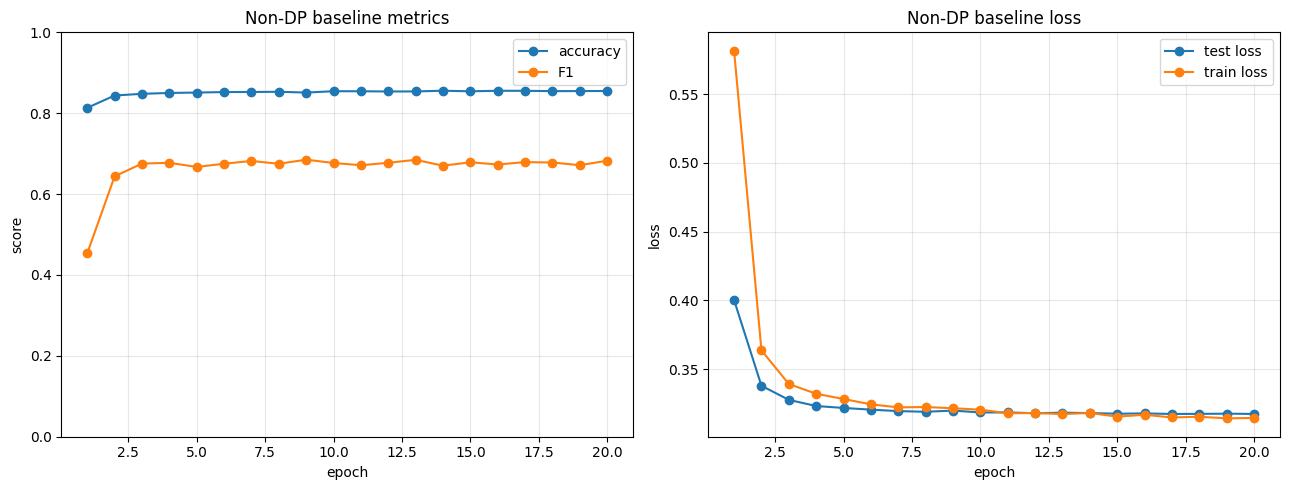

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(non_dp_history_df['epoch'], non_dp_history_df['accuracy'], marker='o', label='accuracy')
axes[0].plot(non_dp_history_df['epoch'], non_dp_history_df['f1'], marker='o', label='F1')
axes[0].set_title('Non-DP baseline metrics')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('score')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(non_dp_history_df['epoch'], non_dp_history_df['test_loss'], marker='o', label='test loss')
axes[1].plot(non_dp_history_df['epoch'], non_dp_history_df['train_loss'], marker='o', label='train loss')
axes[1].set_title('Non-DP baseline loss')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

The tuned non-DP baseline starts weaker in epoch 1, especially on F1, but then improves quickly. Around epoch 3-4 it already reaches roughly `0.85` accuracy and `0.68` F1. Later epochs mostly stabilize, ending around `0.855` accuracy, `0.683` F1 and `0.911` ROC-AUC. This is our upper utility reference, because there is no clipping and no privacy noise.

Now we repeat training with differential privacy. Opacus replaces not only the model and optimizer, but also the training loader. Because of that every epsilon run starts from a fresh model, fresh optimizer and fresh dataloader.

In [33]:
def run_dp_experiment(epsilon, seed):
    train_loader, test_loader = make_loaders(seed)
    model, optimizer = build_adult_model(seed)
    privacy_engine = PrivacyEngine()

    model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        epochs=adult_epochs,
        target_epsilon=epsilon,
        target_delta=adult_delta,
        max_grad_norm=adult_max_grad_norm,
    )

    history = []
    start = time.time()
    for epoch in range(1, adult_epochs + 1):
        train_loss = train_one_epoch_adult(model, train_loader, optimizer, device)
        metrics = evaluate_adult(model, test_loader, device)
        actual_epsilon_now = privacy_engine.get_epsilon(adult_delta)
        row = {
            'method': f'DP eps={epsilon:g}',
            'target_epsilon': epsilon,
            'actual_epsilon': actual_epsilon_now,
            'epoch': epoch,
            'train_loss': train_loss,
            'test_loss': metrics['loss'],
            'accuracy': metrics['accuracy'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1': metrics['f1'],
            'roc_auc': metrics['roc_auc'],
            'pr_auc': metrics['pr_auc'],
        }
        history.append(row)
        print(
            f"epsilon {epsilon:g}, epoch {epoch}: "
            f"actual eps={actual_epsilon_now:.3f}, acc={row['accuracy']:.4f}, "
            f"f1={row['f1']:.4f}, roc_auc={row['roc_auc']:.4f}"
        )

    elapsed = time.time() - start
    final_metrics = evaluate_adult(model, test_loader, device)
    actual_epsilon = privacy_engine.get_epsilon(adult_delta)
    return model, pd.DataFrame(history), final_metrics, actual_epsilon, elapsed


dp_models = {}
dp_histories = []
dp_final_rows = []

for i, epsilon in enumerate(adult_epsilons):
    print(f'\nRunning DP experiment for epsilon={epsilon:g}')
    model, history_df, final_metrics, actual_epsilon, elapsed = run_dp_experiment(
        epsilon=epsilon,
        seed=random_state + 100 + i,
    )
    method_name = f'DP eps={epsilon:g}'
    dp_models[method_name] = model
    dp_histories.append(history_df)
    dp_final_rows.append({
        'method': method_name,
        'target_epsilon': epsilon,
        'actual_epsilon': actual_epsilon,
        'test_loss': final_metrics['loss'],
        'accuracy': final_metrics['accuracy'],
        'precision': final_metrics['precision'],
        'recall': final_metrics['recall'],
        'f1': final_metrics['f1'],
        'roc_auc': final_metrics['roc_auc'],
        'pr_auc': final_metrics['pr_auc'],
        'time_sec': elapsed,
    })

dp_history_df = pd.concat(dp_histories, ignore_index=True)
dp_summary_df = pd.DataFrame(dp_final_rows)

dp_summary_display_df = dp_summary_df.copy()
for col in ['actual_epsilon', 'test_loss', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'time_sec']:
    dp_summary_display_df[col] = dp_summary_display_df[col].round(4)

display(dp_summary_display_df)


Running DP experiment for epsilon=1
epsilon 1, epoch 1: actual eps=0.219, acc=0.7521, f1=0.0000, roc_auc=0.7702
epsilon 1, epoch 2: actual eps=0.305, acc=0.7521, f1=0.0000, roc_auc=0.8498
epsilon 1, epoch 3: actual eps=0.373, acc=0.7521, f1=0.0000, roc_auc=0.8697
epsilon 1, epoch 4: actual eps=0.431, acc=0.7521, f1=0.0000, roc_auc=0.8758
epsilon 1, epoch 5: actual eps=0.483, acc=0.7533, f1=0.0098, roc_auc=0.8789
epsilon 1, epoch 6: actual eps=0.531, acc=0.7575, f1=0.0436, roc_auc=0.8807
epsilon 1, epoch 7: actual eps=0.574, acc=0.7931, f1=0.3189, roc_auc=0.8821
epsilon 1, epoch 8: actual eps=0.615, acc=0.8185, f1=0.4872, roc_auc=0.8833
epsilon 1, epoch 9: actual eps=0.654, acc=0.8293, f1=0.5558, roc_auc=0.8842
epsilon 1, epoch 10: actual eps=0.691, acc=0.8328, f1=0.5927, roc_auc=0.8847
epsilon 1, epoch 11: actual eps=0.726, acc=0.8355, f1=0.6155, roc_auc=0.8855
epsilon 1, epoch 12: actual eps=0.760, acc=0.8356, f1=0.6204, roc_auc=0.8863
epsilon 1, epoch 13: actual eps=0.793, acc=0.836

,method,target_epsilon,actual_epsilon,test_loss,accuracy,precision,recall,f1,roc_auc,pr_auc,time_sec
0,DP eps=1,1.0,0.9951,0.5240,0.8419,0.7333,0.5691,0.6409,0.8937,0.7432,8.5558
1,DP eps=5,5.0,4.9982,0.4884,0.8484,0.7454,0.5901,0.6587,0.9038,0.7668,8.9031
2,DP eps=10,10.0,9.9908,0.4918,0.8515,0.7532,0.5963,0.6657,0.9055,0.7694,9.6755


The epsilon sanity check looks correct. For target `epsilon=1`, Opacus reports about `0.99`; for `5` it reports about `5.00`; and for `10` it reports about `10.00`. So every DP run used a privacy budget very close to the requested value. The first epochs have smaller epsilon because the privacy budget is accumulated during training.

Now we compare all settings together. The non-DP baseline is the utility reference, while smaller epsilon values should protect privacy more strongly but can reduce model quality.

In [34]:
non_dp_summary_row = {
    'method': 'non-DP',
    'target_epsilon': np.inf,
    'actual_epsilon': np.inf,
    'test_loss': non_dp_final_metrics['loss'],
    'accuracy': non_dp_final_metrics['accuracy'],
    'precision': non_dp_final_metrics['precision'],
    'recall': non_dp_final_metrics['recall'],
    'f1': non_dp_final_metrics['f1'],
    'roc_auc': non_dp_final_metrics['roc_auc'],
    'pr_auc': non_dp_final_metrics['pr_auc'],
    'time_sec': non_dp_elapsed,
}

all_summary_df = pd.concat([
    pd.DataFrame([non_dp_summary_row]),
    dp_summary_df,
], ignore_index=True)

all_summary_display_df = all_summary_df.copy()
for col in ['test_loss', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'time_sec']:
    all_summary_display_df[col] = all_summary_display_df[col].round(4)
all_summary_display_df['actual_epsilon'] = all_summary_display_df['actual_epsilon'].replace(np.inf, 'infinity')
all_summary_display_df['target_epsilon'] = all_summary_display_df['target_epsilon'].replace(np.inf, 'infinity')

display(all_summary_display_df)

,method,target_epsilon,actual_epsilon,test_loss,accuracy,precision,recall,f1,roc_auc,pr_auc,time_sec
0,non-DP,infinity,infinity,0.3173,0.8549,0.7460,0.6289,0.6825,0.9108,0.7830,4.2220
1,DP eps=1,1.0,0.9951,0.5240,0.8419,0.7333,0.5691,0.6409,0.8937,0.7432,8.5558
2,DP eps=5,5.0,4.998194,0.4884,0.8484,0.7454,0.5901,0.6587,0.9038,0.7668,8.9031
3,DP eps=10,10.0,9.990821,0.4918,0.8515,0.7532,0.5963,0.6657,0.9055,0.7694,9.6755


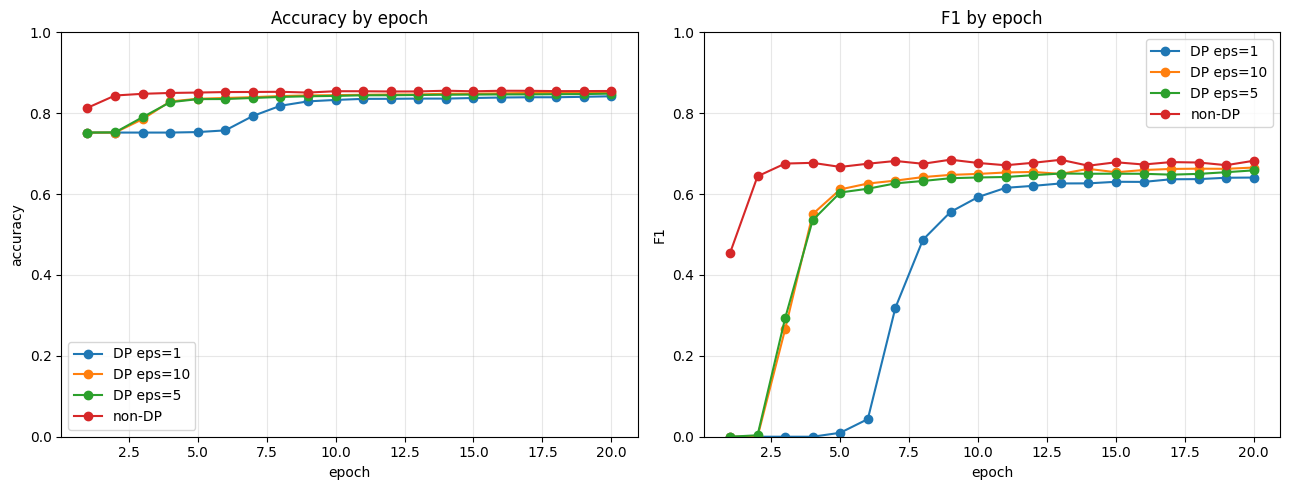

In [35]:
all_history_df = pd.concat([
    non_dp_history_df.assign(target_epsilon=np.inf, actual_epsilon=np.inf),
    dp_history_df,
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for method, method_df in all_history_df.groupby('method'):
    axes[0].plot(method_df['epoch'], method_df['accuracy'], marker='o', label=method)
    axes[1].plot(method_df['epoch'], method_df['f1'], marker='o', label=method)

axes[0].set_title('Accuracy by epoch')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title('F1 by epoch')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('F1')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

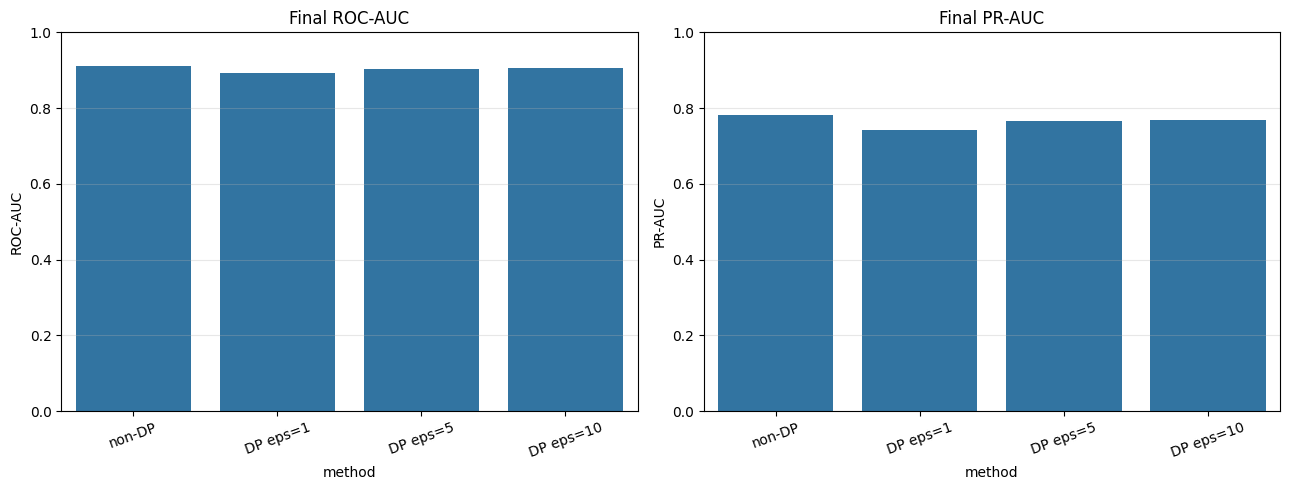

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_order = ['non-DP', 'DP eps=1', 'DP eps=5', 'DP eps=10']

sns.barplot(data=all_summary_df, x='method', y='roc_auc', order=plot_order, ax=axes[0])
axes[0].set_title('Final ROC-AUC')
axes[0].set_xlabel('method')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=all_summary_df, x='method', y='pr_auc', order=plot_order, ax=axes[1])
axes[1].set_title('Final PR-AUC')
axes[1].set_xlabel('method')
axes[1].set_ylabel('PR-AUC')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

The privacy-utility tradeoff is visible, but still moderate. The strongest privacy setting, `epsilon=1`, gives the weakest final F1, about `0.641`. With larger epsilon values the model gets closer to the baseline: `epsilon=10` reaches about `0.852` accuracy and `0.666` F1, while non-DP is still best with about `0.855` accuracy and `0.683` F1. ROC-AUC and PR-AUC show the same pattern: DP loses some utility, but the model remains usable.

Because the dataset is imbalanced, ROC and precision-recall curves are also useful. ROC-AUC shows ranking quality in general, while PR curve focuses more on the positive `>50K` class.

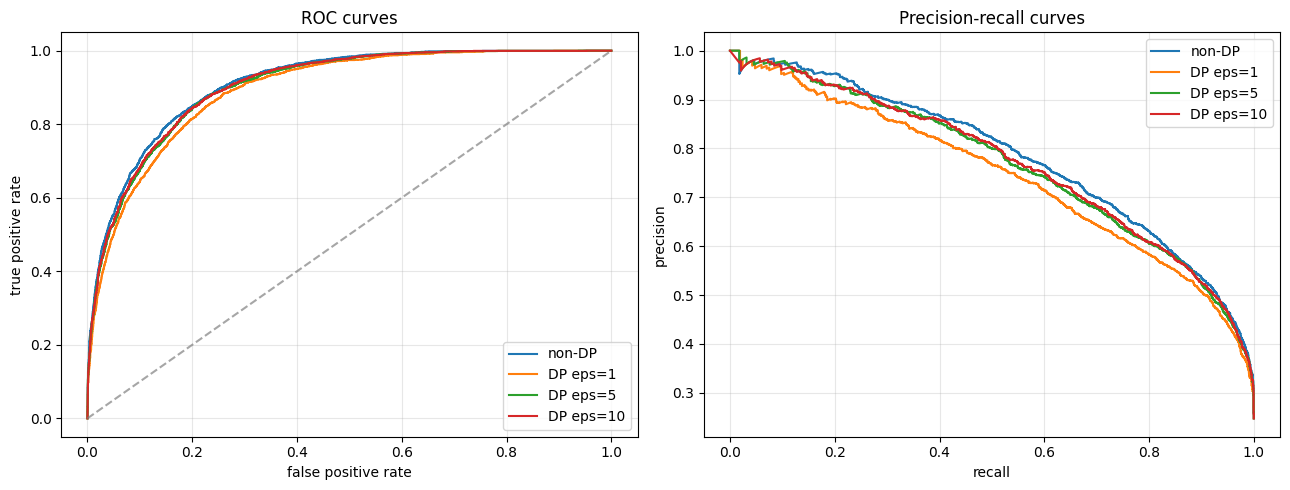

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

curve_sources = {'non-DP': non_dp_final_metrics}
for method_name, model in dp_models.items():
    _, test_loader = make_loaders(random_state)
    curve_sources[method_name] = evaluate_adult(model, test_loader, device)

for method_name in plot_order:
    labels = curve_sources[method_name]['labels']
    probs = curve_sources[method_name]['probs']
    fpr, tpr, _ = roc_curve(labels, probs)
    precision_curve, recall_curve, _ = precision_recall_curve(labels, probs)
    axes[0].plot(fpr, tpr, label=method_name)
    axes[1].plot(recall_curve, precision_curve, label=method_name)

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7)
axes[0].set_title('ROC curves')
axes[0].set_xlabel('false positive rate')
axes[0].set_ylabel('true positive rate')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title('Precision-recall curves')
axes[1].set_xlabel('recall')
axes[1].set_ylabel('precision')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

The ROC and precision-recall curves confirm the table. All DP models still rank examples reasonably well, but the non-DP curve is usually slightly better. The difference is more visible on the precision-recall plot, which matters here because the positive class `>50K` is the minority class.

As a small optional privacy intuition, we compare model confidence on train and test samples. This is not a full membership inference attack, but if the model is much more confident on train than test, it can suggest more memorization.

In [38]:
def confidence_summary(model, loader, device):
    model.eval()
    confidences = []
    correct_flags = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            probs = torch.softmax(model(features), dim=1)
            max_conf, preds = probs.max(dim=1)
            confidences.extend(max_conf.cpu().numpy())
            correct_flags.extend((preds == labels).cpu().numpy())

    confidences = np.array(confidences)
    correct_flags = np.array(correct_flags)
    return {
        'mean_confidence': confidences.mean(),
        'median_confidence': np.median(confidences),
        'mean_confidence_correct': confidences[correct_flags].mean(),
        'mean_confidence_wrong': confidences[~correct_flags].mean(),
    }


confidence_rows = []
models_for_confidence = {'non-DP': non_dp_model, **dp_models}
train_conf_loader = DataLoader(adult_train_dataset, batch_size=adult_test_batch_size, shuffle=False, num_workers=0)
test_conf_loader = DataLoader(adult_test_dataset, batch_size=adult_test_batch_size, shuffle=False, num_workers=0)

for method_name, model in models_for_confidence.items():
    for split_name, loader in [('train', train_conf_loader), ('test', test_conf_loader)]:
        row = confidence_summary(model, loader, device)
        row['method'] = method_name
        row['split'] = split_name
        confidence_rows.append(row)

confidence_df = pd.DataFrame(confidence_rows)
confidence_pivot_df = confidence_df.pivot(index='method', columns='split', values='mean_confidence').reset_index()
confidence_pivot_df['train_test_gap'] = confidence_pivot_df['train'] - confidence_pivot_df['test']

confidence_display_df = confidence_pivot_df.copy()
for col in ['train', 'test', 'train_test_gap']:
    confidence_display_df[col] = confidence_display_df[col].round(4)

display(confidence_display_df)

split,method,test,train,train_test_gap
0,DP eps=1,0.9483,0.9492,0.0009
1,DP eps=10,0.9563,0.9579,0.0016
2,DP eps=5,0.9550,0.9560,0.0010
3,non-DP,0.8499,0.8520,0.0022


This small confidence check does not show a large train-test confidence gap. All methods have a gap close to zero, around `0.001-0.002`, so there is no obvious sign that the model is much more confident on training rows than on test rows. This is only a simple intuition check, not a real membership inference attack. Interestingly, DP models are more confident in absolute value here, so the useful part of this table is mostly the train-test gap, not the raw confidence level.

### Conclusions

Overall, the longer run and small Optuna search still show the same main conclusion. The same selected MLP setup is used for non-DP and all DP runs, so the comparison is fairer than a purely manual choice. Opacus worked as expected and the independent DP runs reached the requested privacy budgets. The non-DP model gives the best utility, around `0.855` accuracy and `0.683` F1. DP with `epsilon=1` is the most private and weakest, while `epsilon=5` and `epsilon=10` move closer to the baseline. The performance loss is visible, but not dramatic for this dataset.

## Problem 7.3: MLOps Pipeline

### Objective
Build complete ML pipeline

### Tasks
- Track experiments using MLflow.
- Version data with DVC.
- Deploy model as REST API using FastAPI.
- Containerize with Docker.
- Implement basic monitoring for predictions.